### DIYAN 
I will use the offficial github repo to implement diayn on our rugby env then try to use it with our two method classical ppo and curriculum 

https://github.com/alirezakazemipour/DIAYN-PyTorch

Ressources used to understand : 
https://arxiv.org/abs/1802.06070
https://towardsai.net/p/l/diayn-diversity-is-all-you-need


> We consider an unsupervised RL paradigm in this work, where the agent is allowed an unsupervised
“exploration” stage followed by a supervised stage. In our work, the aim of the unsupervised stage is
to learn skills that eventually will make it easier to maximize the task reward in the supervised stage.
Conveniently, because skills are learned without a priori knowledge of the task, the learned skills can
be used for many different tasks.

We have the discriminator to identify which skill is executed, predict z.


In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys, os
sys.path.append(os.path.abspath('..'))

import math, random, time
from collections import deque, namedtuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import gymnasium as gym
import matplotlib.pyplot as plt

import src.env  # registers RugbyHRLGame1-v0

# Seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ENV_NAME  = "RugbyHRLGame1-v0"
N_SKILLS  = 3
print(f"Device: {DEVICE}  |  Skills: {N_SKILLS}")


Device: cpu  |  Skills: 3


## Why DIAYN 

The original paper uses **SAC** (Soft Actor-Critic) with a **continuous Gaussian policy**.  
RugbyHRL has a **discrete 6-action space**, so we replace SAC's `PolicyNetwork` with a **discrete actor** (categorical logits).

The core DIAYN idea stays almoast the same:
- Sample a skill $z \sim p(z)$ (uniform) at the start of each episode
- Concatenate $z$ (one-hot) to the observation
- Replace the environment reward with the **discriminator reward**: $r = \log q_\phi(z \mid s') - \log p(z)$
- Train the **discriminator** $q_\phi$ to identify which skill is being executed from the state
- The policy maximises diversity: skills become distinguishable by state-visitation

$$r_\text{DIAYN}(s, z) = \log q_\phi(z \mid s') - \log p(z)$$


## Replay Memory
Sur le github le replay buffer est tres simple, il n'utilise pas d'optimisation particuliere

In [2]:
Transition = namedtuple("Transition", ["state", "z", "done", "action", "next_state"])

class Memory:
    def __init__(self, capacity: int = 100_000):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, z, done, action, next_state):
        self.buffer.append(Transition(state, z, done, action, next_state))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states   = np.stack([t.state      for t in batch])
        zs       = np.stack([t.z          for t in batch])
        dones    = np.array([t.done       for t in batch], dtype=np.float32)
        actions  = np.array([t.action     for t in batch], dtype=np.int64)
        n_states = np.stack([t.next_state for t in batch])
        return states, zs, dones, actions, n_states

    def __len__(self):
        return len(self.buffer)



## Networks (Discrete Adaptation)

| Network | Input | Output |
|---------|-------|--------|
| `Discriminator` | next state `s'` | logits over `N_SKILLS` |
| `DiscreteActor` | state + z (one-hot) | action logits (6 actions) |
| `DiscreteQNetwork` | state + z | Q-value **per action** (6 values) |


In [3]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.orthogonal_(m.weight, gain=math.sqrt(2))
        nn.init.zeros_(m.bias)


class Discriminator(nn.Module):
    def __init__(self, n_states: int, n_skills: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),   nn.Tanh(),
            nn.Linear(hidden, n_skills),
        )
        self.apply(init_weights)

    def forward(self, state):
        return self.net(state)  # logits


class DiscreteActor(nn.Module):
    """Categorical policy π(a|s,z).  Input = concat(state, z_one_hot).
    
    Architecture mirrors the PPO Agent actor:
        Linear(in, 64) → Tanh → Linear(64, 64) → Tanh → Linear(64, n_actions)
    Only the first layer input size differs (state+z vs state alone).
    """
    def __init__(self, n_states: int, n_skills: int, n_actions: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states + n_skills, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),               nn.Tanh(),
            nn.Linear(hidden, n_actions),
        )
        self.apply(init_weights)

    def forward(self, x):
        return self.net(x)  # logits

    def get_action(self, x):
        logits   = self.forward(x)
        dist     = Categorical(logits=logits)
        action   = dist.sample()
        log_prob = dist.log_prob(action)
        probs    = dist.probs           # (batch, n_actions)
        return action, log_prob, probs


class DiscreteQNetwork(nn.Module):
    """Q(s,z,·): returns one Q-value per action.  Input = concat(state, z_one_hot).
    
    Same hidden architecture as the PPO critic (64 units, Tanh).
    """
    def __init__(self, n_states: int, n_skills: int, n_actions: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_states + n_skills, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),               nn.Tanh(),
            nn.Linear(hidden, n_actions),
        )
        self.apply(init_weights)

    def forward(self, x):
        return self.net(x)  # (batch, n_actions)


print("Networks defined ✓  (hidden=64, Tanh — matches PPO architecture)")


Networks defined ✓  (hidden=64, Tanh — matches PPO architecture)


## DIAYN Agent (Discrete SAC)

In **discrete SAC** the value function is computed analytically (no sampling):

$$V(s,z) = \sum_a \pi(a|s,z) \left[ Q(s,z,a) - \alpha \log \pi(a|s,z) \right]$$

The policy loss (minimised w.r.t. actor):

$$\mathcal{L}_\pi = \mathbb{E}_{s,z} \left[ \sum_a \pi(a|s,z) \left( \alpha \log \pi(a|s,z) - Q(s,z,a) \right) \right]$$

The temperature $\alpha$ is auto-tuned to match a target entropy $\mathcal{H}^* = \log(|\mathcal{A}|) \times 0.95$.


In [4]:
class DIAYNAgent:
    def __init__(self, n_states, n_skills, n_actions, cfg):
        self.n_states  = n_states
        self.n_skills  = n_skills
        self.n_actions = n_actions
        self.cfg       = cfg
        self.device    = DEVICE

        self.actor      = DiscreteActor(n_states, n_skills, n_actions).to(DEVICE)
        self.q1         = DiscreteQNetwork(n_states, n_skills, n_actions).to(DEVICE)
        self.q2         = DiscreteQNetwork(n_states, n_skills, n_actions).to(DEVICE)
        self.q1_target  = DiscreteQNetwork(n_states, n_skills, n_actions).to(DEVICE)
        self.q2_target  = DiscreteQNetwork(n_states, n_skills, n_actions).to(DEVICE)
        self.discriminator = Discriminator(n_states, n_skills).to(DEVICE)

        self.q1_target.load_state_dict(self.q1.state_dict())
        self.q2_target.load_state_dict(self.q2.state_dict())

        lr      = cfg["lr"]
        lr_crit = cfg.get("lr_critic", lr)
        self.actor_opt  = optim.Adam(self.actor.parameters(),         lr=lr)
        self.q1_opt     = optim.Adam(self.q1.parameters(),            lr=lr_crit)
        self.q2_opt     = optim.Adam(self.q2.parameters(),            lr=lr_crit)
        self.disc_opt   = optim.Adam(self.discriminator.parameters(), lr=lr)

        # target entropy = 0.6 * log(|A|)  — less aggressive than 0.95
        self.target_entropy = math.log(n_actions) * 0.6
        self.log_alpha = torch.zeros(1, requires_grad=True, device=DEVICE)
        self.alpha_opt = optim.Adam([self.log_alpha], lr=cfg.get("alpha_lr", 3e-4))

        self.max_grad_norm = cfg.get("max_grad_norm", 0.5)
        self.memory = Memory(cfg.get("memory_capacity", 100_000))

#clamp the alpha to avoid exploding
    @property
    def alpha(self):
        return self.log_alpha.clamp(min=-5.0, max=2.0).exp()  

    def _to(self, arr, dtype=torch.float32):
        return torch.tensor(arr, dtype=dtype, device=DEVICE)

    def _sz(self, state, z_onehot):
        return np.concatenate([state, z_onehot], axis=-1)

    def one_hot(self, z: int):
        oh = np.zeros(self.n_skills, dtype=np.float32)
        oh[z] = 1.0
        return oh

    @torch.no_grad()
    def choose_action(self, state, z_onehot):
        x = self._to(self._sz(state, z_onehot)).unsqueeze(0)
        logits = self.actor(x)
        dist   = Categorical(logits=logits)
        return dist.sample().item()

    def store(self, state, z_onehot, done, action, next_state):
        self.memory.add(state, z_onehot, done, action, next_state)

    @torch.no_grad()
    def diayn_reward(self, next_state_t, z_idx: int):
        """r = log q(z|s') - log p(z), clipped to [-5, 5] for stability."""
        logits = self.discriminator(next_state_t)
        log_q  = F.log_softmax(logits, dim=-1)
        log_p  = -math.log(self.n_skills)
        r      = log_q[:, z_idx] - log_p
        return r.clamp(-5.0, 5.0).unsqueeze(1)

    def train(self, z_batch_idx):
        """One gradient step."""
        cfg        = self.cfg
        batch_size = cfg["batch_size"]
        if len(self.memory) < batch_size:
            return {}

        states, zs, dones, actions, next_states = self.memory.sample(batch_size)

        states_t      = self._to(states)
        zs_t          = self._to(zs)
        dones_t       = self._to(dones).unsqueeze(1)
        actions_t     = torch.tensor(actions, dtype=torch.long, device=DEVICE).unsqueeze(1)
        next_states_t = self._to(next_states)

        sz      = torch.cat([states_t,      zs_t], dim=-1)
        next_sz = torch.cat([next_states_t, zs_t], dim=-1)

        z_idx_t = zs_t.argmax(dim=-1)   # (B,)

        # ── intrinsic rewards (no grad) ───────────────────────────────────────
        with torch.no_grad():
            logits  = self.discriminator(next_states_t)
            log_q   = F.log_softmax(logits, dim=-1)
            log_p   = math.log(1.0 / self.n_skills)
            rewards = (log_q.gather(1, z_idx_t.unsqueeze(1)) - log_p).clamp(-5.0, 5.0)

        # ── discriminator ─────────────────────────────────────────────────────
        disc_logits = self.discriminator(next_states_t)
        disc_loss   = F.cross_entropy(disc_logits, z_idx_t)
        self.disc_opt.zero_grad()
        disc_loss.backward()
        nn.utils.clip_grad_norm_(self.discriminator.parameters(), self.max_grad_norm)
        self.disc_opt.step()

        # ── critics ───────────────────────────────────────────────────────────
        with torch.no_grad():
            next_logits    = self.actor(next_sz)
            next_probs     = F.softmax(next_logits, dim=-1)
            next_log_probs = F.log_softmax(next_logits, dim=-1)
            next_q_min     = torch.min(self.q1_target(next_sz), self.q2_target(next_sz))
            next_v         = (next_probs * (next_q_min - self.alpha * next_log_probs)).sum(dim=-1, keepdim=True)
            target_q       = rewards + cfg["gamma"] * (1.0 - dones_t) * next_v

        q1_pred = self.q1(sz).gather(1, actions_t)
        q2_pred = self.q2(sz).gather(1, actions_t)
        q1_loss = F.mse_loss(q1_pred, target_q)
        q2_loss = F.mse_loss(q2_pred, target_q)
        for opt, loss, net in [(self.q1_opt, q1_loss, self.q1), (self.q2_opt, q2_loss, self.q2)]:
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), self.max_grad_norm)
            opt.step()

        # ── actor ─────────────────────────────────────────────────────────────
        logits    = self.actor(sz)
        probs     = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            q_min = torch.min(self.q1(sz), self.q2(sz))
        actor_loss = (probs * (self.alpha.detach() * log_probs - q_min)).sum(dim=-1).mean()
        self.actor_opt.zero_grad(); actor_loss.backward()
        nn.utils.clip_grad_norm_(self.actor.parameters(), self.max_grad_norm)
        self.actor_opt.step()

        # ── alpha ─────────────────────────────────────────────────────────────
        entropy    = -(probs.detach() * log_probs.detach()).sum(dim=-1).mean()
        alpha_loss = self.log_alpha * (entropy - self.target_entropy)
        self.alpha_opt.zero_grad(); alpha_loss.backward(); self.alpha_opt.step()

        # ── soft update target nets ───────────────────────────────────────────
        tau = cfg["tau"]
        for p, tp in zip(self.q1.parameters(), self.q1_target.parameters()):
            tp.data.copy_(tau * p.data + (1 - tau) * tp.data)
        for p, tp in zip(self.q2.parameters(), self.q2_target.parameters()):
            tp.data.copy_(tau * p.data + (1 - tau) * tp.data)

        return dict(
            disc_loss  = disc_loss.item(),
            q1_loss    = q1_loss.item(),
            q2_loss    = q2_loss.item(),
            actor_loss = actor_loss.item(),
            alpha      = self.alpha.item(),
            entropy    = entropy.item(),
        )

    def save(self, path: str):
        torch.save({
            "actor":         self.actor.state_dict(),
            "q1":            self.q1.state_dict(),
            "q2":            self.q2.state_dict(),
            "discriminator": self.discriminator.state_dict(),
        }, path)
        print(f"Saved → {path}")

    def load(self, path: str):
        ckpt = torch.load(path, map_location=DEVICE)
        self.actor.load_state_dict(ckpt["actor"])
        self.q1.load_state_dict(ckpt["q1"])
        self.q2.load_state_dict(ckpt["q2"])
        self.discriminator.load_state_dict(ckpt["discriminator"])
        self.q1_target.load_state_dict(ckpt["q1"])
        self.q2_target.load_state_dict(ckpt["q2"])
        print(f"Loaded ← {path}")


print("DIAYNAgent defined ✓")


DIAYNAgent defined ✓


## Environment Setup & Hyperparameters

In [5]:
env      = gym.make(ENV_NAME)
OBS_DIM  = env.observation_space.shape[0]   # 21
N_ACTIONS = env.action_space.n              # 6
env.close()
print(f"obs_dim={OBS_DIM}  n_actions={N_ACTIONS}  n_skills={N_SKILLS}")

CFG = dict(
    lr               = 3e-4,
    lr_critic        = 1e-4,   # lower LR for Q-networks to prevent divergence
    alpha_lr         = 1e-4,   # slower alpha adaptation
    gamma            = 0.99,
    tau              = 0.005,
    batch_size       = 256,
    memory_capacity  = 200_000,
    max_episodes     = 1500,
    max_steps        = 300,
    train_every      = 1,
    warmup_steps     = 2_000,
    log_every        = 50,
    checkpoint_every = 500,
    checkpoint_dir   = "checkpoints/diayn",
    max_grad_norm    = 1.0,    # increased from 0.5
)

os.makedirs(CFG["checkpoint_dir"], exist_ok=True)

# ── agent ─────────────────────────────────────────────────────────────────────
agent = DIAYNAgent(OBS_DIM, N_SKILLS, N_ACTIONS, CFG)
print("Agent ready ✓")


obs_dim=21  n_actions=6  n_skills=3


/home/wboussella/Documents/RugbyHRL/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Agent ready ✓


## Training Loop

Each episode:
1. Sample skill $z \sim \text{Uniform}(0, N\_SKILLS-1)$
2. Encode $z$ as one-hot and concatenate to every observation
3. Replace environment reward with **DIAYN intrinsic reward** $r = \log q_\phi(z|s') - \log p(z)$
4. Store transitions in the replay buffer and call one SAC update step

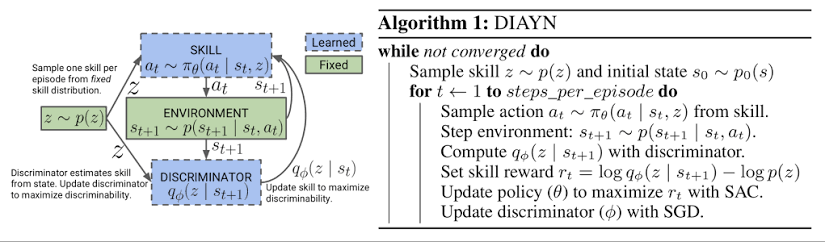


In [6]:
env      = gym.make(ENV_NAME)
total_steps = 0
history  = []          # list of dicts for logging
log_buf  = {k: [] for k in ("disc_loss","q1_loss","q2_loss","actor_loss","alpha","entropy","ep_reward")}


In [7]:

for ep in range(1, CFG["max_episodes"] + 1):
    z        = random.randint(0, N_SKILLS - 1)
    z_onehot = agent.one_hot(z)

    obs, _   = env.reset(seed=SEED + ep)
    done     = False
    ep_reward = 0.0
    ep_intrinsic = 0.0

    for step in range(CFG["max_steps"]):
        action = agent.choose_action(obs, z_onehot)
        next_obs, _env_reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        ns_t    = torch.tensor(next_obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        r_intr  = agent.diayn_reward(ns_t, z).item()
        ep_intrinsic += r_intr

        agent.store(obs, z_onehot, float(done), action, next_obs)
        total_steps += 1
        obs          = next_obs
        ep_reward   += r_intr       # track intrinsic reward as proxy

        if total_steps >= CFG["warmup_steps"] and step % CFG["train_every"] == 0:
            metrics = agent.train(z)
            if metrics:
                for k, v in metrics.items():
                    log_buf[k].append(v)

        if done:
            break

    log_buf["ep_reward"].append(ep_reward)

    # ── logging ───────────────────────────────────────────────────────────────
    if ep % CFG["log_every"] == 0:
        avg = {k: (sum(v[-CFG["log_every"]:]) / max(len(v[-CFG["log_every"]:]), 1))
               for k, v in log_buf.items()}
        print(f"Ep {ep:5d}  steps={total_steps:7d}  "
              f"intr_r={avg['ep_reward']:+6.2f}  "
              f"disc={avg['disc_loss']:.3f}  "
              f"α={avg['alpha']:.4f}  "
              f"H={avg['entropy']:.3f}")
        history.append({"ep": ep, **avg})

    if ep % CFG["checkpoint_every"] == 0:
        agent.save(os.path.join(CFG["checkpoint_dir"], f"diayn_ep{ep}.pth"))

env.close()
print("Training complete ✓")


KeyboardInterrupt: 

## Training Curves

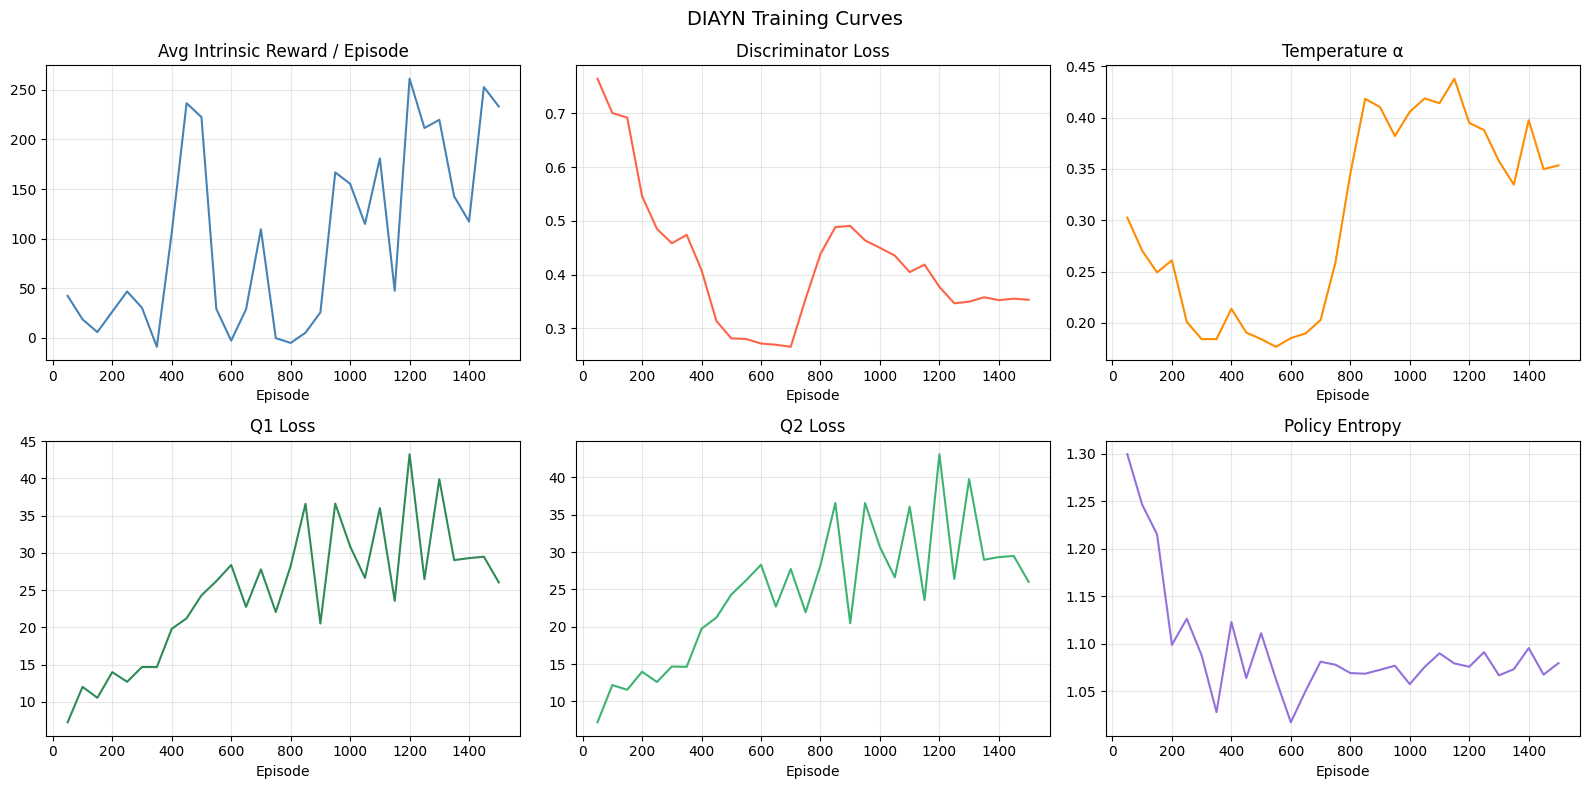

: 

In [ ]:
if not history:
    print("No history yet — run the training loop first.")
else:
    eps   = [h["ep"]        for h in history]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle("DIAYN Training Curves", fontsize=14)

    def _plot(ax, key, label, colour="steelblue"):
        vals = [h[key] for h in history]
        ax.plot(eps, vals, colour, linewidth=1.5)
        ax.set_title(label); ax.set_xlabel("Episode"); ax.grid(alpha=0.3)

    _plot(axes[0,0], "ep_reward",  "Avg Intrinsic Reward / Episode")
    _plot(axes[0,1], "disc_loss",  "Discriminator Loss",  "tomato")
    _plot(axes[0,2], "alpha",      "Temperature α",       "darkorange")
    _plot(axes[1,0], "q1_loss",    "Q1 Loss",             "seagreen")
    _plot(axes[1,1], "q2_loss",    "Q2 Loss",             "mediumseagreen")
    _plot(axes[1,2], "entropy",    "Policy Entropy",      "mediumpurple")

    plt.tight_layout()
    plt.savefig(os.path.join(CFG["checkpoint_dir"], "training_curves.png"), dpi=120)
    plt.show()


## Watch Each Skill Play (5 seconds per skill)
Load the latest checkpoint and render each of the `N_SKILLS` skills for 5 seconds so you can visually inspect the learned behaviours.

In [ ]:
# ── standalone guard ──────────────────────────────────────────────────────────
import sys, os, math, random, time
sys.path.append(os.path.abspath('..'))
import numpy as np
import torch
import torch.nn.functional as F
from torch.distributions import Categorical
import gymnasium as gym
import src.env

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ENV_NAME = "RugbyHRLGame1-v0"
N_SKILLS = 3

if "CFG" not in dir():
    CFG = dict(lr=3e-4, alpha_lr=3e-4, gamma=0.99, tau=0.005,
               batch_size=256, memory_capacity=200_000,
               max_episodes=1500, max_steps=300, train_every=1,
               warmup_steps=2_000, log_every=50, checkpoint_every=500,
               checkpoint_dir="checkpoints/diayn", max_grad_norm=1.0,
               lr_critic=1e-4)
if "OBS_DIM" not in dir():
    _env = gym.make(ENV_NAME)
    OBS_DIM = _env.observation_space.shape[0]
    N_ACTIONS = _env.action_space.n
    _env.close()

WATCH_CHECKPOINT  = os.path.join(CFG["checkpoint_dir"], f"diayn_ep{CFG['max_episodes']}.pth")
SECONDS_PER_SKILL = 5
FPS = 30

if not os.path.exists(WATCH_CHECKPOINT):
    print(f"⚠  Checkpoint not found: {WATCH_CHECKPOINT}")
    print("   Run the training loop first.")
else:
    try:
        import pygame
        pygame.init()

        watch_agent = DIAYNAgent(OBS_DIM, N_SKILLS, N_ACTIONS, CFG)
        watch_agent.load(WATCH_CHECKPOINT)

        watch_env = gym.make(ENV_NAME, render_mode="human")
        watch_env.reset()
        watch_env.render()
        clock    = pygame.time.Clock()
        font_hud = pygame.font.SysFont("monospace", 28, bold=True)

        for z in range(N_SKILLS):
            z_onehot = watch_agent.one_hot(z)
            watch_env.close()
            watch_env = gym.make(ENV_NAME, render_mode="human")
            obs, _    = watch_env.reset()
            watch_env.render()
            surface   = pygame.display.get_surface()

            # splash
            deadline = time.time() + 1.5
            while time.time() < deadline:
                for ev in pygame.event.get():
                    if ev.type == pygame.QUIT: raise SystemExit
                surface.fill((20,20,20))
                lbl = font_hud.render(f"SKILL {z}/{N_SKILLS-1}", True, (255,255,80))
                sw,sh = surface.get_size()
                surface.blit(lbl, (sw//2-lbl.get_width()//2, sh//2-lbl.get_height()//2))
                pygame.display.flip(); clock.tick(FPS)

            # play
            total_r, step = 0.0, 0
            print(f"\n▶  Skill {z}/{N_SKILLS-1}")
            deadline = time.time() + SECONDS_PER_SKILL
            while time.time() < deadline:
                for ev in pygame.event.get():
                    if ev.type == pygame.QUIT: raise SystemExit
                action = watch_agent.choose_action(obs, z_onehot)
                obs, r, term, trunc, _ = watch_env.step(action)
                total_r += r; step += 1
                watch_env.render()
                if term or trunc: obs, _ = watch_env.reset()
                clock.tick(FPS)
            print(f"   Skill {z} — steps: {step}  reward: {total_r:.2f}")

        watch_env.close()
        pygame.quit()
        print("\nDone watching all skills.")

    except Exception as exc:
        print(f"⚠  Renderer failed: {exc}")
        print("   Tip: pygame display requires a connected monitor or Xvfb.")
        try: watch_env.close()
        except: pass
        try: pygame.quit()
        except: pass

Loaded ← checkpoints/diayn/diayn_ep1500.pth
